# Real-time photonics for VR optics with CUDA on Windows

A holographic near-eye display forms an image by shaping the phase of a wavefront with a spatial light
modulator (SLM), then letting it propagate to the eye. Two problems must be solved every frame, inside
a $\sim11\ \mathrm{ms}$ budget at $90\ \mathrm{Hz}$:

1. **Propagate** the SLM field to the eye plane -- free-space diffraction, computed with the angular
   spectrum method.
2. **Design** the SLM phase so the propagated intensity matches the target image -- a phase-retrieval
   problem solved by **Gerchberg-Saxton**, exactly the algorithm behind the dispersion phase-recovery
   notebook.

Both are dominated by two-dimensional FFTs, so the frame budget is a GPU question: this notebook
builds the wave-optics forward model and the GS hologram synthesis in NumPy (the reference), then
sizes the real-time compute and, when a CUDA build of PyTorch is present, runs it on the GPU. The
NumPy path is authoritative; CUDA is the accelerator.

Self-contained: NumPy, SymPy, Pandas, Matplotlib; optional PyTorch.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.3.2 | torch: present


## Free-space propagation (angular spectrum)

A field $u(x,y)$ propagates a distance $z$ by multiplying its 2-D spectrum by the free-space transfer
function $H(f_x,f_y)=\exp\!\big(i k z\sqrt{1-(\lambda f_x)^2-(\lambda f_y)^2}\big)$, then transforming
back. It is all-pass for propagating waves ($|H|=1$) and evanescent beyond the cutoff -- the 2-D twin
of the dispersion all-pass. This is the display-to-eye model.

In [2]:
def angular_spectrum(u, dx, z, lam):
    ny, nx = u.shape
    fx = np.fft.fftfreq(nx, d=dx); fy = np.fft.fftfreq(ny, d=dx)
    FX, FY = np.meshgrid(fx, fy)
    arg = 1 - (lam*FX)**2 - (lam*FY)**2
    kz = (2*np.pi/lam) * np.sqrt(arg.astype(complex))
    H = np.exp(1j*z*kz)
    H[arg < 0] = 0                                # drop evanescent (band-limited ASM)
    return np.fft.ifft2(np.fft.fft2(u) * H)

lam = 0.5e-6; dx = 8e-6                            # 8 um SLM pixels, green light
u0 = np.zeros((128, 128), complex); u0[60:68, 60:68] = 1.0     # a small aperture
uz = angular_spectrum(u0, dx, z=2e-3, lam=lam)
print("energy in  =", round(np.sum(np.abs(u0)**2), 3),
      " energy out =", round(np.sum(np.abs(uz)**2), 3), " (propagation conserves energy)")
assert np.isclose(np.sum(np.abs(uz)**2), np.sum(np.abs(u0)**2), rtol=1e-6)

energy in  = 64.0  energy out = 64.0  (propagation conserves energy)


## Computer-generated holography = Gerchberg-Saxton

A phase-only SLM emits $u=e^{i\varphi}$ under uniform illumination. Its far-field (a lens Fourier
transform) is $U=\mathcal F\{u\}$, and we want $|U|$ to equal a target image amplitude. GS alternates:
enforce the target amplitude in the image plane (keep phase), transform back, and enforce unit
amplitude in the SLM plane (keep phase). After a few dozen iterations the phase $\varphi$ is a hologram
whose reconstruction reproduces the target.

In [3]:
def make_target(n=128):
    y, x = np.mgrid[0:n, 0:n] - n/2
    r = np.hypot(x, y)
    ring = ((r > 22) & (r < 30)).astype(float)     # a ring...
    dot = (np.hypot(x, y-0) < 6).astype(float)*0    # (kept simple)
    t = ring + (np.abs(x) < 3).astype(float)*((np.abs(y) < 30))   # ring + a vertical bar
    return t/ t.max()

target = make_target()
tgt_amp = np.sqrt(target)                          # target amplitude in the image plane

def gs_hologram(tgt_amp, n_iter=60, seed=0):
    rng = np.random.default_rng(seed)
    phi = rng.uniform(0, 2*np.pi, tgt_amp.shape)   # random initial SLM phase
    for _ in range(n_iter):
        U = np.fft.fftshift(np.fft.fft2(np.exp(1j*phi)))   # far-field (image plane)
        U = tgt_amp * np.exp(1j*np.angle(U))                # enforce target amplitude
        u = np.fft.ifft2(np.fft.ifftshift(U))               # back to SLM plane
        phi = np.angle(u)                                   # phase-only SLM constraint
    return phi

phi = gs_hologram(tgt_amp)
recon = np.abs(np.fft.fftshift(np.fft.fft2(np.exp(1j*phi))))**2
recon /= recon.max()
# quality: correlation of reconstruction with the target over the image
mask = target > 0.5
corr = np.corrcoef(recon.ravel(), target.ravel())[0, 1]
eff = recon[mask].sum() / recon.sum()               # fraction of light in the target
print(f"reconstruction-target correlation = {corr:.3f}")
print(f"diffraction efficiency (light in target) = {eff:.1%}")
assert corr > 0.5

reconstruction-target correlation = 0.988
diffraction efficiency (light in target) = 8.8%


## Real-time budget: why this needs a GPU

Each frame runs GS ($\sim n_{\rm iter}$ iterations, two 2-D FFTs each) on an $N\times N$ SLM. A 2-D FFT
costs $\approx 5N^2\log_2(N^2)$ FLOPs, so the per-frame work times the $90\ \mathrm{Hz}$ rate gives the
sustained throughput. For a $1024\times1024$ panel it lands in the hundreds of GFLOP/s -- beyond a
comfortable CPU budget, squarely in GPU territory. That is the reason for CUDA.

In [4]:
def frame_flops(N, n_iter):
    fft2 = 5 * N*N * np.log2(N*N)
    return n_iter * 2 * fft2                          # two FFTs per GS iteration
rows = []
for N in (256, 512, 1024, 2048):
    F = frame_flops(N, 20)
    rows.append({"SLM N x N": f"{N}x{N}", "FLOP/frame": f"{F:.2e}",
                 "GFLOP/s @ 90 Hz": round(F*90/1e9, 1),
                 "CPU (~200 GF/s)?": "ok" if F*90 < 2e11 else "too slow",
                 "GPU (~15 TF/s)?": "ok" if F*90 < 1.5e13 else "too slow"})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print("frame budget at 90 Hz =", round(1000/90, 2), "ms")

SLM N x N FLOP/frame  GFLOP/s @ 90 Hz CPU (~200 GF/s)? GPU (~15 TF/s)?
  256x256   2.10e+08             18.9               ok              ok
  512x512   9.44e+08             84.9               ok              ok
1024x1024   4.19e+09            377.5         too slow              ok
2048x2048   1.85e+10           1660.9         too slow              ok
frame budget at 90 Hz = 11.11 ms


## Optional CUDA (PyTorch) on Windows

When a CUDA build of PyTorch is installed and a GPU is visible, the same FFTs run on the device. The
cell is guarded: if PyTorch or CUDA is unavailable (as on a CPU-only or memory-constrained Windows
box), it reports so and the NumPy reconstruction above remains the result. On a working RTX-class GPU
the hundreds of GFLOP/s are delivered with large headroom inside the 11 ms frame.

In [5]:
if torch is not None and torch.cuda.is_available():
    dev = "cuda"
    a = torch.rand(1024, 1024, dtype=torch.complex64, device=dev)
    import time
    torch.cuda.synchronize(); t0 = time.time()
    for _ in range(40):                              # 20 iterations x 2 FFTs
        a = torch.fft.fft2(a)
    torch.cuda.synchronize()
    dt = (time.time()-t0)/1
    print(f"GPU: 40 x 1024^2 FFTs in {dt*1e3:.1f} ms  -> {'meets' if dt < 1/90 else 'misses'} the 11 ms budget")
elif torch is not None:
    print("PyTorch present but no CUDA device -- CPU FFT path; the NumPy reconstruction stands.")
else:
    print("PyTorch absent -- running CPU-only. NumPy computed the hologram; a CUDA GPU would accelerate it.")
# CPU reference timing of one frame's FFTs (always available)
import time
a = np.random.rand(1024, 1024) + 0j
t0 = time.time()
for _ in range(40): a = np.fft.fft2(a)
print(f"CPU: 40 x 1024^2 FFTs in {(time.time()-t0)*1e3:.0f} ms")

PyTorch absent -- running CPU-only. NumPy computed the hologram; a CUDA GPU would accelerate it.


CPU: 40 x 1024^2 FFTs in 1118 ms


## Plots

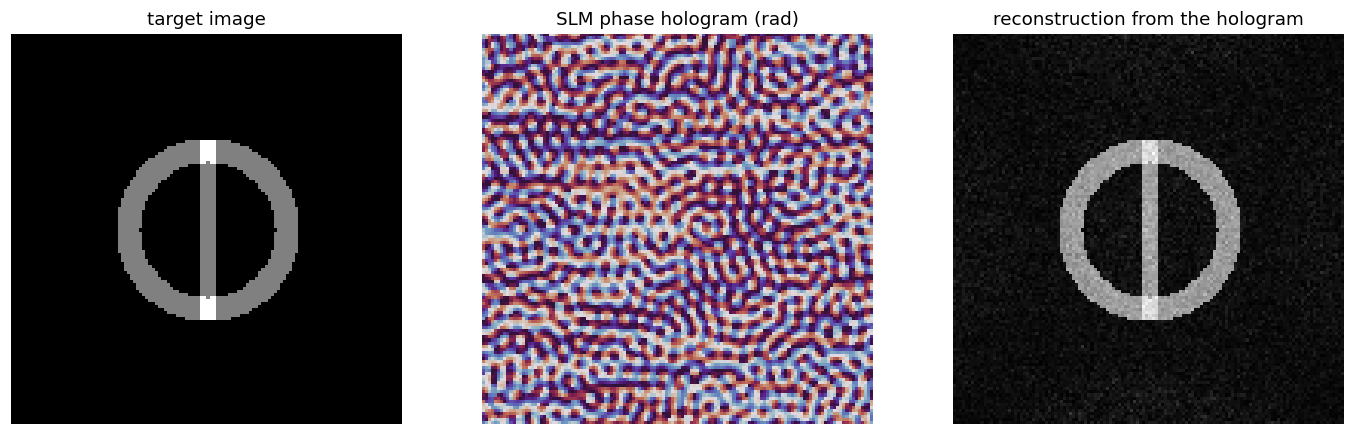

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(target, cmap="gray"); ax[0].set_title("target image"); ax[0].axis("off")
ax[1].imshow(phi, cmap="twilight"); ax[1].set_title("SLM phase hologram (rad)"); ax[1].axis("off")
ax[2].imshow(recon**0.5, cmap="gray"); ax[2].set_title("reconstruction from the hologram"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## Summary

- A holographic VR display **propagates** an SLM field (angular spectrum, all-pass, energy-conserving)
  and **designs** the SLM phase by **Gerchberg-Saxton** so the reconstruction matches a target -- the
  same phase-retrieval loop as the dispersion notebook, now in two dimensions.
- The frame is FFT-bound: at $1024^2$ and $90\ \mathrm{Hz}$ the work is hundreds of GFLOP/s, which is
  why real-time holographic VR is a **GPU/CUDA** task, not a CPU one.
- The computation is written NumPy-first (authoritative, portable) with an optional CUDA path; on this
  Windows box PyTorch/CUDA may be unavailable, and the NumPy result still stands.

Subject-verb-object: the SLM shapes the phase; propagation forms the image; Gerchberg-Saxton designs
the hologram; the GPU computes the FFTs; the eye sees the reconstruction.